# Reasoning NCA: Test-Time Scaling & Niche-Capped Pruning (Sudoku-Extreme)

Accompanying reproduction notebook to run **progressive niche-capped candidate pruning** for test-time scaling (TTS) on a subset of the **Sudoku-Extreme** test-set.

**Pruning Strategy:**
A rollout of horizon $D$ is divided into $m$ equal segments ($m \in \{2, 4, 8\}$). At the end of each intermediate segment, the $K$ parallel candidate trajectories per puzzle are scored by mean cell prediction confidence. To prevent premature mode collapse onto identical high-confidence grids, **niche capping** allows at most $m_{\text{cap}} = 3$ copies of any identical predicted grid to survive, and the top half ($K/2$) of survivors continue into the next segment. This yields the geometric compute reduction:

$$\text{FLOPs}(D, m) = \text{FLOPs}_{\text{base}}(D) \cdot \frac{2 - 2^{-(m-1)}}{m}$$

**Usage:** Select a runtime (GPU recommended), run the cells and upload checkpoint files (`config.json`, `ema_params.pickle`) to `checkpoints/Sudoku-Extreme/` in the left sidebar (`Files 📁`) when prompted.

In [1]:
#@title Installs & Environment Check

!pip install -q ml-collections einops seaborn

import csv
from functools import partial
import json
import os
import pickle
import shutil
import time
import urllib.request

from einops import rearrange
import jax
from jax import jit, lax, vmap
import jax.numpy as jnp
import jax.random as jr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import ml_collections
from ml_collections import config_dict
import numpy as np
import pandas as pd
import seaborn as sns

print(f"JAX version: {jax.__version__}")
print(f"Available JAX devices ({len(jax.local_devices())}): {jax.local_devices()}")
print(f"Default backend: {jax.default_backend()}")

JAX version: 0.11.1
Available JAX devices (1): [CudaDevice(id=0)]
Default backend: gpu


## 1. Reasoning NCA Model & Configuration (`config.py`, `nca.py`)

In [2]:
#@title config.py
import jax
from ml_collections import config_dict


# ------------------------------------------------------------------------------
# Config
# ------------------------------------------------------------------------------
config = config_dict.ConfigDict()

# Random seed
config.RANDOM_SEED = 0

# Available devices
config.NUM_DEVICES = len(jax.local_devices())

# NCA
config.H = 9
config.W = 9
config.DTYPE = "float32"  # "bfloat16"
config.CHANNEL_N = 256
config.NUM_UNITS = 4
config.INPUT_EMB_D = config.get_ref("CHANNEL_N") // config.get_ref("NUM_UNITS")
config.OUTPUT_EMB_D = config.get_ref("CHANNEL_N") // config.get_ref("NUM_UNITS")
config.VOCAB_SIZE = 10
config.INIT_TYPE = "random"  # "zeros" or "random"
config.INIT_NOISE_STD = 0.25
config.NUM_LAYERS = 1
config.SENSING_TYPE = "fixed_attention"  # "convolution", "fixed_attention" or "self_attention"
config.SENSING_PADDING = "wrap"  # "wrap" or "token"
config.PADDING_TOKEN_ID = 0
config.SENSING_NORM = "none"  # "softmax", "l2" or "none"
config.SENSING_HEADS = 16
config.UPDATE_TYPE = "mlp"  # "mlp" or "swiglu"
config.UPDATE_EXPANSION = 4
config.CELL_FIRE_RATE = 0.8
config.STEP_SIZE = 1.0
config.PRED_TYPE = "cosine_similarity"  # "mlp", "cosine_similarity", "l2_similarity"
config.CONF_TYPE = "max"  # "mlp" or "max"
config.CONNECTIVITY = "local"  # "local" or "global"
config.NORMALIZATION = "group_norm"  # "none", "group_norm" or "rms_norm"
config.NORM_EPS = 1e-6

# TRAINING
config.OUTPUT_DIR = ""
config.DSET_NAME = "sext"
config.DSET_MAX_SIZE = -1  # -1 for all
config.DSET_AUG = True
config.STEPS_N = 100000
config.EVAL_EVERY = 100
config.CHECKPOINT_EVERY = 1000
config.BATCH_SIZE = 800
config.EVAL_BATCH_SIZE = 1000
config.TEST_BATCH_SIZE = 1000
config.ROLLOUT_WITH_NOISE = True
config.NOISE_P = 0.1
config.NOISE_SP = 0.2
config.NOISE_STD = 0.15
config.DAMAGE_P = 0.1
config.DAMAGE_N = 4
config.CHANGE_P = 0.1
config.LOSS_TYPE = "mse"  # "mse" or "ce"
config.LOSS_CONF_COEF = 0.5
config.LOSS_APPLY = "all"  # "all" or "last"
config.OPTIMIZER = "adamw"  # "adamw", "adamw_atan2", "muon" or "adamuon"
config.ADAMW_FOR_INPUT_OUTPUT = True
config.INIT_LR_RATIO = 10.0
config.LEARNING_RATE = 1e-4
config.LR_WARMUP_RATIO = 0.02
config.END_LR_RATIO = 1.0
config.GRADIENT_CLIPPING = True
config.WEIGHT_DECAY = 1e-4
config.BETA_1 = 0.9
config.BETA_2 = 0.95
config.EMA_DECAY = 0.999
config.T = 3
config.CHUNK_N = 24
config.EVAL_ITER_N = 1152
config.TEST_ITER_N = 1152
config.HALT_CONF_THRESH = 0.9  # 0, 0.9
# Pooling
config.POOL_SIZE_RATIO = 4
config.POOL_SIZE = config.get_ref("POOL_SIZE_RATIO") * config.get_ref(
    "BATCH_SIZE"
)
config.BATCH_SEED_RATIO = 0.25
config.BATCH_SEED_N = (
    config.get_ref("BATCH_SEED_RATIO") * config.get_ref("BATCH_SIZE")
).to_int()

In [3]:
#@title nca.py

@partial(jit, static_argnames=("num_units", "norm_eps"))
def group_norm(emb, num_units=1, norm_eps=1e-6):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  emb_normalized = emb / (
      jnp.linalg.norm(emb, axis=-1, keepdims=True) + norm_eps
  )
  emb = emb_normalized.reshape(orig_shape)
  return emb


@partial(jit, static_argnames=("num_units", "norm_eps"))
def rms_norm(emb, num_units=1, norm_eps=1e-6):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  emb_normalized = (
      emb / (jnp.mean(emb**2, axis=-1, keepdims=True) + norm_eps) ** 0.5
  )
  emb = emb_normalized.reshape(orig_shape)
  return emb


@jit
def init_state(key, input_masks, target_grids, input_embeddings):
  input_grids = input_masks * target_grids

  if config.INIT_TYPE == "zeros":
    x0 = jnp.zeros(input_grids.shape + (config.CHANNEL_N,), dtype=config.DTYPE)
    if config.NORMALIZATION != "none":
      x0 = x0 + 1.0
    x0 = x0.at[..., : config.INPUT_EMB_D].set(input_embeddings[input_grids])
  elif config.INIT_TYPE == "random":
    k1, key = jr.split(key)
    x0 = (
        jr.normal(
            k1,
            shape=input_grids.shape + (config.CHANNEL_N,),
            dtype=config.DTYPE,
        )
        * config.INIT_NOISE_STD
    )
    input_emb_mask = input_masks[..., None] & (
        jnp.arange(x0.shape[-1]) < config.INPUT_EMB_D
    )
    x0_input = x0.at[..., : config.INPUT_EMB_D].set(
        input_embeddings[input_grids]
    )
    x0 = jnp.where(input_emb_mask, x0_input, x0)
  else:
    raise ValueError(f"Unknown init type: {config.INIT_TYPE}")

  if config.NORMALIZATION == "none":
    pass
  elif config.NORMALIZATION == "group_norm":
    x0 = group_norm(x0, config.NUM_UNITS, config.NORM_EPS)
  elif config.NORMALIZATION == "rms_norm":
    x0 = rms_norm(x0, config.NUM_UNITS, config.NORM_EPS)
  else:
    raise ValueError(f"Unknown normalization: {config.NORMALIZATION}")

  return x0


@partial(jit, static_argnames=("num_units",))
def proj_emb(emb, vector, num_units):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  vector = vector.reshape(
      orig_shape[:-1] + (num_units, orig_shape[-1] // num_units)
  )
  projected_emb = jnp.sum(emb * vector, axis=-1, keepdims=True) * vector
  emb = emb - projected_emb
  emb = emb.reshape(orig_shape)
  return emb


@jit
def pad_with_vector(x, vector):
  H, W, C = x.shape
  vector = vector[None, None, :]
  side_border = jnp.tile(vector, (H, 1, 1))
  middle_section = jnp.concatenate([side_border, x, side_border], axis=1)
  top_bottom_row = jnp.tile(vector, (1, W + 2, 1))
  x_pad = jnp.concatenate(
      [top_bottom_row, middle_section, top_bottom_row], axis=0
  )
  return x_pad


@jit
def stack_neighbors(x, vector=None):
  if config.SENSING_PADDING == "token_emb":
    x_pad = pad_with_vector(x, vector)
  else:
    x_pad = jnp.pad(x, ((1, 1), (1, 1), (0, 0)), mode=config.SENSING_PADDING)
  neighbors_x = jnp.stack(
      [
          x_pad[:-2, :-2, :],
          x_pad[:-2, 1:-1, :],
          x_pad[:-2, 2:, :],
          x_pad[1:-1, :-2, :],
          x_pad[1:-1, 1:-1, :],
          x_pad[1:-1, 2:, :],
          x_pad[2:, :-2, :],
          x_pad[2:, 1:-1, :],
          x_pad[2:, 2:, :],
      ],
      axis=-2,
  )
  return neighbors_x


@jit
def sensing_normalize(scores):
  if config.SENSING_NORM == "none":
    return scores
  elif config.SENSING_NORM == "softmax":
    return jax.nn.softmax(scores, axis=-1)
  elif config.SENSING_NORM == "l2":
    return scores / jnp.linalg.norm(scores, axis=-1, keepdims=True)
  else:
    raise ValueError(f"Unknown attention normalization: {config.SENSING_NORM}")


@jit
def nca_step(params, x, key, is_input):
  update_mask = jr.bernoulli(
      key,
      shape=x.shape[:-1] + (1,),
      p=config.CELL_FIRE_RATE,
  ).astype(config.DTYPE)

  for l_idx in range(config.NUM_LAYERS):
    l_idx = str(l_idx)

    if config.CONNECTIVITY == "local":
      neighbors_x = stack_neighbors(
          x, params["input_embed"][config.PADDING_TOKEN_ID]
      )
      if config.SENSING_TYPE == "convolution":
        scores = params["sensing"][l_idx]["kernels"]
        scores = sensing_normalize(scores)
        z = jnp.einsum("M N, W H N C -> M W H N C", scores, neighbors_x)
        z = rearrange(z, "M W H N C -> W H N (M C)")
        z = z.sum(-2)
      elif "attention" in config.SENSING_TYPE:
        if config.SENSING_TYPE == "self_attention":
          xx, yy = jnp.meshgrid(jnp.arange(config.W), jnp.arange(config.H))
          pe = params["sensing"][l_idx]["pe"][yy * config.W + xx]
          neighbors_pe = stack_neighbors(pe)
          query = jnp.einsum(
              "M D E, W H E -> W H M D", params["sensing"][l_idx]["q"], x + pe
          )
          query = rearrange(query, "W H M D -> W H M () D")
          keys = jnp.einsum(
              "M D E, W H N E -> W H M N D",
              params["sensing"][l_idx]["k"],
              neighbors_x + neighbors_pe,
          )
          scores = jnp.matmul(query, jnp.swapaxes(keys, -1, -2)) / (
              keys.shape[-1] ** 0.5
          )
          scores = sensing_normalize(scores)
          values = jnp.einsum(
              "M D E, W H N E -> W H M N D",
              params["sensing"][l_idx]["v"],
              neighbors_x + neighbors_pe,
          )
        elif config.SENSING_TYPE == "fixed_attention":
          scores = params["sensing"][l_idx]["fixed_attention"]
          scores = sensing_normalize(scores)
          values = jnp.einsum(
              "M D E, W H N E -> W H M N D",
              params["sensing"][l_idx]["v"],
              neighbors_x,
          )
        else:
          raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")
        z = jnp.matmul(scores, values)[:, :, :, 0, :]
        z = rearrange(z, "W H M D -> W H (M D)")
      else:
        raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")

    elif config.CONNECTIVITY == "global":
      if config.SENSING_TYPE == "self_attention":
        xx, yy = jnp.meshgrid(jnp.arange(config.W), jnp.arange(config.H))
        pe = params["sensing"][l_idx]["pe"][yy * config.W + xx]
        q = jnp.einsum(
            "M D E, W H E -> M W H D", params["sensing"][l_idx]["q"], x + pe
        )
        k = jnp.einsum(
            "M D E, W H E -> M W H D", params["sensing"][l_idx]["k"], x + pe
        )
        v = jnp.einsum(
            "M D E, W H E -> M W H D", params["sensing"][l_idx]["v"], x + pe
        )
        q = q.reshape(q.shape[0], -1, q.shape[-1])
        k = k.reshape(k.shape[0], -1, k.shape[-1])
        v = v.reshape(v.shape[0], -1, v.shape[-1])
        scores = jnp.matmul(q, jnp.swapaxes(k, -1, -2)) / (k.shape[-1] ** 0.5)
        scores = sensing_normalize(scores)
      elif config.SENSING_TYPE == "fixed_attention":
        v = jnp.einsum(
            "M D E, W H E -> M W H D", params["sensing"][l_idx]["v"], x
        )
        v = v.reshape(v.shape[0], -1, v.shape[-1])
        scores = params["sensing"][l_idx]["fixed_attention"]
        scores = sensing_normalize(scores)
      else:
        raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")
      z = jnp.matmul(scores, v)
      z = rearrange(z, "M N D -> N (M D)")
      z = z.reshape(config.W, config.H, -1)
    else:
      raise ValueError(f"Unknown connectivity: {config.CONNECTIVITY}")

    if config.UPDATE_TYPE == "mlp":
      dx = (params["update"][l_idx]["w1"] @ z[..., None])[..., 0] + params["update"][l_idx]["b1"]
      dx = jax.nn.relu(dx)
      dx = (params["update"][l_idx]["w2"] @ dx[..., None])[..., 0] + params["update"][l_idx]["b2"]
    elif config.UPDATE_TYPE == "swiglu":
      gate, up = jnp.split(
          (params["update"][l_idx]["w1"] @ z[..., None])[..., 0]
          + params["update"][l_idx]["b1"],
          2,
          -1,
      )
      dx = (params["update"][l_idx]["w2"] @ (jax.nn.swish(gate) * up)[..., None])[
          ..., 0
      ] + params["update"][l_idx]["b2"]
    else:
      raise ValueError(f"Unknown update type: {config.UPDATE_TYPE}")

    dx = dx * update_mask
    input_emb_mask = is_input[:, :, None] & (
        jnp.arange(dx.shape[-1]) < config.INPUT_EMB_D
    )
    dx = jnp.where(input_emb_mask, 0.0, dx)

    if config.NORMALIZATION == "none":
      x = x + config.STEP_SIZE * dx
    elif config.NORMALIZATION == "group_norm":
      dx = proj_emb(dx, x, config.NUM_UNITS)
      x = x + config.STEP_SIZE * dx
      x = group_norm(x, config.NUM_UNITS, config.NORM_EPS)
    elif config.NORMALIZATION == "rms_norm":
      x = x + config.STEP_SIZE * dx
      x = rms_norm(x, config.NUM_UNITS, config.NORM_EPS)
    else:
      raise ValueError(f"Unknown normalization: {config.NORMALIZATION}")

  return x


@jit
def nca_pred(params, x):
  output_emb = x[..., : config.OUTPUT_EMB_D]
  if config.PRED_TYPE == "mlp":
    logits = (params["pred_head"]["w"] @ output_emb[..., None])[
        ..., 0
    ] + params["pred_head"]["b"]
  elif config.PRED_TYPE == "cosine_similarity":
    x_norm = jnp.linalg.norm(output_emb, axis=-1) + 1e-6
    input_emb = params["input_embed"][:, : config.OUTPUT_EMB_D]
    tokens_norm = jnp.linalg.norm(input_emb, axis=-1) + 1e-6
    logits = jnp.dot(output_emb, input_emb.T) / (
        x_norm[..., None] * tokens_norm[None, :]
    )
  elif config.PRED_TYPE == "l2_similarity":
    input_emb = params["input_embed"][:, : config.OUTPUT_EMB_D]
    dist = jnp.linalg.norm(
        output_emb.reshape(-1, config.OUTPUT_EMB_D)[:, None, :]
        - input_emb[None, :, :],
        axis=-1,
    ).reshape(output_emb.shape[:-1] + (config.VOCAB_SIZE,))
    logits = 1.0 / (1.0 + dist)
  else:
    raise ValueError(f"Unknown prediction head: {config.PRED_TYPE}")

  if config.CONF_TYPE == "mlp":
    conf = (params["conf_head"]["w"] @ output_emb[..., None])[..., 0] + params[
        "conf_head"
    ]["b"]
  elif config.CONF_TYPE == "max":
    if config.PRED_TYPE == "mlp":
      conf = jax.nn.softmax(logits, axis=-1).max(axis=-1)
    elif "similarity" in config.PRED_TYPE:
      conf = logits.max(axis=-1)
    else:
      raise ValueError(f"Unknown prediction head: {config.PRED_TYPE}")
  else:
    raise ValueError(f"Unknown confidence head: {config.PRED_TYPE}")

  return output_emb, logits, conf


b_nca_pred = vmap(nca_pred, in_axes=(None, 0))


@partial(jit, static_argnames=("iter_n", "return_full"))
def nca_rollout_noise(
    params,
    x0,
    key,
    is_input,
    noise_tp,
    noise_sp,
    noise_std,
    iter_n,
    return_full=False,
    sg_at_idx=-1,
):
  def scan_f(carry, i):
    x, key = carry
    x = jax.lax.cond(i == sg_at_idx, lambda: lax.stop_gradient(x), lambda: x)
    k1, key = jr.split(key)
    x = nca_step(params, x, k1, is_input)

    k1, k2, k3, key = jr.split(key, 4)
    noise_mask = jr.bernoulli(
        k1,
        shape=(1,),
        p=noise_tp[i],
    ) * jr.bernoulli(
        k2,
        shape=x.shape[:-1] + (1,),
        p=noise_sp[i],
    )
    noise_mask = noise_mask.repeat(config.CHANNEL_N, axis=-1).astype(
        config.DTYPE
    )

    input_emb_mask = is_input[:, :, None] & (
        jnp.arange(x.shape[-1]) < config.INPUT_EMB_D
    )
    noise_mask = jnp.where(input_emb_mask, 0.0, noise_mask)

    noise = (jr.normal(k3, shape=x.shape) * noise_std[i]).astype(config.DTYPE)
    x = x + noise * noise_mask
    return (x, key), x

  (x, key), xs = lax.scan(
      scan_f, (x0, key), jnp.arange(0, iter_n, dtype=jnp.int32)
  )
  return xs if return_full else x


def update_config(**kwargs):
  for k, v in kwargs.items():
    config[k] = v
  init_state.clear_cache()
  stack_neighbors.clear_cache()
  sensing_normalize.clear_cache()
  nca_step.clear_cache()
  nca_pred.clear_cache()
  nca_rollout_noise.clear_cache()

## 2. Niche-Capped Pruning Primitives & FLOP Accounting (`prune.py`)

In [4]:
#@title prune.py (Progressive Niche-Capped Candidate Pruning & FLOPs)

BENCHMARK = "sext"
SEXT_DIFFICULTY_KEYS = [
    "0-1-a",
    "1-2-a",
    "2-6-a",
    "6-11-a",
    "11-16-a",
    "16-21-a",
    "21-27-a",
    "27-33-a",
    "33-42-a",
    "42-54-a",
    "54-290-a",
]

# Evaluation-time rollout: no gradients, only final state returned to bound peak GPU memory.
b_nca_rollout_noise_eval = vmap(
    partial(nca_rollout_noise, return_full=False, sg_at_idx=-1),
    in_axes=(None, 0, 0, 0, None, None, None, None),
)


@partial(jax.jit, static_argnames=("m_cap", "keep_count"))
def prune_puzzle_seeds(state, preds, conf, m_cap: int, keep_count: int):
  """Keeps the `keep_count` most confident candidates of a single puzzle.

  Candidates predicting an identical grid form a "niche"; at most `m_cap` of
  them may survive, preserving solution diversity instead of collapsing onto
  many copies of one confident answer.
  """
  s = state.shape[0]
  p_confs = jnp.mean(conf, axis=(-1, -2))
  p_grids = jnp.argmax(preds, axis=-1).reshape(s, -1)

  matches = jnp.all(p_grids[:, None, :] == p_grids[None, :, :], axis=-1)
  idx = jnp.arange(s)
  better_mask = (p_confs[None, :] > p_confs[:, None]) | (
      (p_confs[None, :] == p_confs[:, None]) & (idx[None, :] < idx[:, None])
  )
  clone_rank = jnp.sum(better_mask & matches, axis=-1)
  adjusted_confs = jnp.where(clone_rank < m_cap, p_confs, -999.0)

  sorted_order = jnp.argsort(-adjusted_confs)
  top_indices = sorted_order[:keep_count]
  return state[top_indices]


@partial(jax.jit, static_argnames=("m_cap", "keep_count"))
def prune_batch_seeds(state, preds, conf, m_cap: int, keep_count: int):
  """Applies `prune_puzzle_seeds` independently to every puzzle in a batch."""
  return vmap(
      partial(prune_puzzle_seeds, m_cap=m_cap, keep_count=keep_count),
      in_axes=(0, 0, 0),
  )(state, preds, conf)


@jax.jit
def evaluate_batch_accuracy(preds, conf, targets):
  """Counts exactly solved puzzles, scoring each by its most confident seed."""
  conf_mean = jnp.mean(conf, axis=(-1, -2))
  best_seed_idx = jnp.argmax(conf_mean, axis=-1)
  b = preds.shape[0]
  best_preds = preds[jnp.arange(b), best_seed_idx]
  is_exact = jnp.all(
      jnp.argmax(best_preds, axis=-1) == jnp.argmax(targets, axis=-1),
      axis=(-1, -2),
  )
  return jnp.sum(is_exact)


def step_flops(params, x0, key, input_mask) -> float:
  """FLOPs of a single NCA update step for one candidate."""
  lowered = jax.jit(nca_step).lower(params, x0, key, input_mask)
  return float(lowered.compile().cost_analysis()["flops"])


def pred_flops(params, x0) -> float:
  """FLOPs of a single grid readout for one candidate."""
  lowered = jax.jit(nca_pred).lower(params, x0)
  return float(lowered.compile().cost_analysis()["flops"])


def theoretical_flop_saving(m: int) -> float:
  """Fraction of rollout FLOPs saved by pruning with divisor `m`."""
  return 1.0 - (2.0 - 2.0 ** (-(m - 1))) / m

## 3. Download Sudoku-Extreme Test Dataset Online & Build Subset

In [5]:
#@title Download Sudoku-Extreme (`sapientinc/sudoku-extreme`) from HuggingFace

def parse_sext_csv(url_or_path, indices=None):
  df = pd.read_csv(url_or_path)
  inputs, targets, difficulties = [], [], []
  sub_df = df if indices is None else df.iloc[indices]
  for _, row in sub_df.iterrows():
    q = str(row["question"])
    a = str(row["answer"])
    inputs.append(
        np.frombuffer(q.replace(".", "0").encode(), dtype=np.uint8).reshape(9, 9)
        - ord("0")
    )
    targets.append(
        np.frombuffer(a.encode(), dtype=np.uint8).reshape(9, 9) - ord("0")
    )
    difficulties.append(int(row["rating"]))

  inputs_np = np.array(inputs, dtype=np.uint8)
  input_masks = (inputs_np > 0).astype(bool)
  targets_np = np.array(targets, dtype=np.uint8)
  difficulties_np = np.array(difficulties, dtype=np.uint16)
  return {
      "input_masks": input_masks,
      "input_grids": (input_masks * targets_np).astype(np.uint8),
      "target_grids": targets_np,
      "difficulties": difficulties_np,
  }


def load_sext_test_dset(cache_dir="/content/dataset/Sudoku-Extreme"):
  os.makedirs(cache_dir, exist_ok=True)
  local_csv_path = os.path.join(cache_dir, "test.csv")
  url_sext = "https://huggingface.co/datasets/sapientinc/sudoku-extreme/resolve/main/test.csv"

  if not os.path.exists(local_csv_path):
    print(f"Downloading Sudoku-Extreme test.csv from {url_sext}...")
    urllib.request.urlretrieve(url_sext, local_csv_path)
    print(f"Saved local copy to {local_csv_path}.")
  else:
    print(f"Using cached Sudoku-Extreme test.csv at {local_csv_path}.")

  parsed = parse_sext_csv(local_csv_path)
  inputs = parsed["input_grids"]
  input_masks = parsed["input_masks"]
  targets = parsed["target_grids"]
  difficulties = parsed["difficulties"]

  dset = {}
  difficulty_bin_edges = [0, 1, 2, 6, 11, 16, 21, 27, 33, 42, 54, 289 + 1]
  for bin_left, bin_right in zip(
      difficulty_bin_edges[:-1], difficulty_bin_edges[1:]
  ):
    in_bin = np.logical_and(difficulties >= bin_left, difficulties < bin_right)
    bin_inputs = inputs[in_bin]
    bin_input_masks = input_masks[in_bin]
    bin_targets = targets[in_bin]
    bin_diffs = difficulties[in_bin]

    n_examples = len(bin_inputs)
    n_sub_bins = max(1, (n_examples + 9999) // 10000)
    for i in range(n_sub_bins):
      suffix = ""
      temp = i
      while True:
        suffix = chr(ord("a") + (temp % 26)) + suffix
        temp = temp // 26 - 1
        if temp < 0:
          break
      d = f"{int(bin_left)}-{int(bin_right)}-{suffix}"
      start_idx = i * 10000
      end_idx = min((i + 1) * 10000, n_examples)
      dset[d] = {
          "input_grids": bin_inputs[start_idx:end_idx],
          "input_masks": bin_input_masks[start_idx:end_idx],
          "target_grids": bin_targets[start_idx:end_idx],
          "difficulties": bin_diffs[start_idx:end_idx],
      }

  return dset


def build_sext_subset(dsets_raw, dset_size_per_bin: int = 10):
  """Extracts `dset_size_per_bin` samples from each of the 11 difficulty bins (-1 for full)."""
  all_inputs, all_masks, all_targets = [], [], []
  for diff in SEXT_DIFFICULTY_KEYS:
    data = dsets_raw[diff]
    n_samples = (
        data["input_grids"].shape[0]
        if dset_size_per_bin == -1
        else min(dset_size_per_bin, data["input_grids"].shape[0])
    )
    all_inputs.append(data["input_grids"][:n_samples])
    all_masks.append(data["input_masks"][:n_samples])
    all_targets.append(data["target_grids"][:n_samples])

  return {
      "inputs": jnp.concatenate([jnp.array(x) for x in all_inputs], axis=0),
      "input_masks": jnp.concatenate([jnp.array(x) for x in all_masks], axis=0),
      "targets": jnp.concatenate([jnp.array(x) for x in all_targets], axis=0),
  }


if "sext_dset_raw" not in globals():
  sext_dset_raw = load_sext_test_dset()

print(
    "Sudoku-Extreme bins loaded ("
    + ", ".join([f"{k}: {len(sext_dset_raw[k]['input_masks'])}" for k in SEXT_DIFFICULTY_KEYS])
    + ")"
)

Using cached Sudoku-Extreme test.csv at /content/dataset/Sudoku-Extreme/test.csv.
Sudoku-Extreme bins loaded (0-1-a: 10000, 1-2-a: 10000, 2-6-a: 10000, 6-11-a: 10000, 11-16-a: 10000, 16-21-a: 10000, 21-27-a: 10000, 27-33-a: 10000, 33-42-a: 10000, 42-54-a: 10000, 54-290-a: 10000)


## 4. Load Pretrained Sudoku-Extreme Checkpoint (`config.json`, `ema_params.pickle`)

In [6]:
#@title create checkpoint dirs
checkpoint_dir = "/content/checkpoints/Sudoku-Extreme"
if not os.path.exists(checkpoint_dir):
  os.makedirs(checkpoint_dir)

In [7]:
#@title alert user to load checkpoints files
# Note: Ignore this warning if you have already uploaded 'config.json' and 'ema_params.pickle' to checkpoints/Sudoku-Extreme/.
from IPython.display import Javascript, display

display(
    Javascript("""
    alert(`⚠️ ACTION REQUIRED: Upload Checkpoints
(Ignore this warning if you have already uploaded the checkpoint files.)

Please upload 'config.json' and 'ema_params.pickle' for Sudoku-Extreme:

📁 Target folder structure in left sidebar (Files 📁):
checkpoints/Sudoku-Extreme/

Example:
  checkpoints/Sudoku-Extreme/config.json
  checkpoints/Sudoku-Extreme/ema_params.pickle`);
""")
)

<IPython.core.display.Javascript object>

In [8]:
#@title load params and configs
import json
import pickle

with open("/content/checkpoints/Sudoku-Extreme/config.json", "r") as f:
  checkpoint_config = json.load(f)

update_config(**checkpoint_config)

with open("/content/checkpoints/Sudoku-Extreme/ema_params.pickle", "rb") as f:
  params_exp = pickle.load(f)

first_diff_key = SEXT_DIFFICULTY_KEYS[0]
input_mask_dummy = sext_dset_raw[first_diff_key]["input_masks"][0]
target_grid_dummy = sext_dset_raw[first_diff_key]["target_grids"][0]
x0_dummy = init_state(
    jr.PRNGKey(0),
    input_mask_dummy,
    target_grid_dummy,
    params_exp["input_embed"],
)

instance_flops_step = step_flops(
    params_exp, x0_dummy, jr.PRNGKey(0), input_mask_dummy
)
instance_flops_pred = pred_flops(params_exp, x0_dummy)

print(f"Loaded Sudoku-Extreme NCA checkpoint ({config.CHANNEL_N} channels, {config.SENSING_HEADS} heads).")
print(f"Single NCA step FLOPs per candidate: {instance_flops_step:,.0f}")
print(f"Single readout FLOPs per candidate:  {instance_flops_pred:,.0f}")

Loaded Sudoku-Extreme NCA checkpoint (256 channels, 16 heads).
Single NCA step FLOPs per candidate: 943,778
Single readout FLOPs per candidate:  8,172


## 5. TTS Pruning Evaluation (`test_prune.py`)

In [9]:
#@title test_prune.py

def evaluate_pruning(
    params_exp,
    run_dset: dict,
    seeds_n: int = 128,
    t_horizon: int = 256,
    mode: str = "pruned",
    k: int = 4,
    eval_seed: int = 0,
    batch_size: int = 11,
    m_cap: int = 3,
    noise_fraction: float = 0.25,
    noise_p: float = 0.1,
    noise_sp: float = 0.2,
    noise_std: float = 0.3,
    verbose: bool = True,
) -> dict:
  """Evaluates one (K, D, strategy, seed) configuration."""
  total_samples = len(run_dset["inputs"])
  batch_size = min(batch_size, total_samples)
  num_batches = total_samples // batch_size
  eval_samples = num_batches * batch_size

  def get_batch_local(indices, batch_seed_idx):
    input_masks = run_dset["input_masks"][indices]
    target_grids = run_dset["targets"][indices]
    init_key = jr.PRNGKey(eval_seed * 1_000_000 + batch_seed_idx * 7919)
    x0 = init_state(
        init_key, input_masks, target_grids, params_exp["input_embed"]
    )
    y = jax.nn.one_hot(target_grids, num_classes=config.VOCAB_SIZE)
    return x0, y, input_masks

  unpruned_flops = (
      eval_samples
      * seeds_n
      * ((t_horizon * instance_flops_step) + instance_flops_pred)
  )

  t_noise_limit = int(noise_fraction * t_horizon)
  noise_tp_full = jnp.where(jnp.arange(t_horizon) < t_noise_limit, noise_p, 0.0)
  noise_sp_full = jnp.where(jnp.arange(t_horizon) < t_noise_limit, noise_sp, 0.0)
  noise_std_full = jnp.where(
      jnp.arange(t_horizon) < t_noise_limit, noise_std, 0.0
  )

  total_solved = 0
  total_flops_accum = 0.0
  cumulative_time_sec = 0.0

  if mode == "baseline":
    if verbose:
      print(
          f"\n--- Running Baseline (Unpruned) | K={seeds_n}, D={t_horizon}, "
          f"seed={eval_seed}, samples={eval_samples} (batch_size={batch_size}) ---"
      )
    for batch_idx in range(num_batches):
      tb_start = time.time()
      batch_ids = np.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
      x0_test, y_test, input_mask_test = get_batch_local(batch_ids, batch_idx)

      x0_ens = jnp.repeat(x0_test, seeds_n, axis=0)
      mask_ens = jnp.repeat(input_mask_test, seeds_n, axis=0)
      ens_keys = jax.random.split(
          jr.PRNGKey(eval_seed * 1_000_000 + batch_idx * 31 + 42),
          x0_ens.shape[0],
      )

      final_state = b_nca_rollout_noise_eval(
          params_exp,
          x0_ens,
          ens_keys,
          mask_ens,
          noise_tp_full,
          noise_sp_full,
          noise_std_full,
          t_horizon,
      )
      final_state.block_until_ready()

      _, preds, conf = b_nca_pred(params_exp, final_state)
      preds_b = preds.reshape(batch_size, seeds_n, *preds.shape[1:])
      conf_b = conf.reshape(batch_size, seeds_n, *conf.shape[1:])
      batch_correct = int(evaluate_batch_accuracy(preds_b, conf_b, y_test))
      total_solved += batch_correct

      tb_elapsed = time.time() - tb_start
      cumulative_time_sec += tb_elapsed

      if verbose:
        current_samples = (batch_idx + 1) * batch_size
        print(
            f"  Batch [{batch_idx + 1}/{num_batches}] | "
            f"Solved: {total_solved}/{current_samples} ({total_solved / current_samples * 100:.2f}%) | "
            f"Batch Time: {tb_elapsed:.2f}s"
        )

    final_acc = total_solved / max(eval_samples, 1)
    return {
        "benchmark": BENCHMARK,
        "K": seeds_n,
        "T": t_horizon,
        "type": "baseline",
        "eval_seed": eval_seed,
        "eval_samples": eval_samples,
        "total_solved": total_solved,
        "acc": final_acc,
        "flops": unpruned_flops,
        "flop_saving": 0.0,
        "theoretical_flop_saving": 0.0,
        "time_seconds": cumulative_time_sec,
        "throughput_samples_per_sec": eval_samples / max(cumulative_time_sec, 1e-4),
    }

  else:
    segment_len = t_horizon // k
    if segment_len >= t_horizon or segment_len < 1:
      raise ValueError(
          f"Invalid segment_len {segment_len} for T={t_horizon}, k={k}"
      )

    if verbose:
      print(
          f"\n--- Running Niche-Capped Pruned (m={k}, m_cap={m_cap}) | "
          f"K={seeds_n}, D={t_horizon} (segment_len={segment_len}), "
          f"seed={eval_seed}, samples={eval_samples} ---"
      )

    for batch_idx in range(num_batches):
      tb_start = time.time()
      batch_ids = np.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
      x0_test, y_test, input_mask_test = get_batch_local(batch_ids, batch_idx)

      current_state_b = jnp.repeat(x0_test[:, None, ...], seeds_n, axis=1)
      current_seeds_n = seeds_n
      batch_key = jr.PRNGKey(eval_seed * 1_000_000 + batch_idx * 31 + 42)

      for step in range(0, t_horizon, segment_len):
        current_len = min(segment_len, t_horizon - step)
        if current_len <= 0:
          break

        segment_steps = jnp.arange(step, step + current_len)
        noise_mask_seg = segment_steps < t_noise_limit
        noise_tp_seg = jnp.where(noise_mask_seg, noise_p, 0.0)
        noise_sp_seg = jnp.where(noise_mask_seg, noise_sp, 0.0)
        noise_std_seg = jnp.where(noise_mask_seg, noise_std, 0.0)

        total_flops_accum += (batch_size * current_seeds_n) * (
            current_len * instance_flops_step
        )
        current_state_flat = current_state_b.reshape(
            batch_size * current_seeds_n, *current_state_b.shape[2:]
        )
        mask_flat = jnp.repeat(input_mask_test, current_seeds_n, axis=0)
        batch_key, step_key = jr.split(batch_key)
        keys_flat = jax.random.split(step_key, batch_size * current_seeds_n)

        rolled_state_flat = b_nca_rollout_noise_eval(
            params_exp,
            current_state_flat,
            keys_flat,
            mask_flat,
            noise_tp_seg,
            noise_sp_seg,
            noise_std_seg,
            current_len,
        )

        if step + current_len >= t_horizon:
          current_state_flat = rolled_state_flat
          current_state_b = current_state_flat.reshape(
              batch_size, current_seeds_n, *current_state_flat.shape[1:]
          )
          break

        total_flops_accum += (
            batch_size * current_seeds_n
        ) * instance_flops_pred
        _, preds, conf = b_nca_pred(params_exp, rolled_state_flat)

        preds_b = preds.reshape(batch_size, current_seeds_n, *preds.shape[1:])
        conf_b = conf.reshape(batch_size, current_seeds_n, *conf.shape[1:])
        rolled_state_b = rolled_state_flat.reshape(
            batch_size, current_seeds_n, *rolled_state_flat.shape[1:]
        )

        keep_count = max(1, current_seeds_n // 2)
        current_state_b = prune_batch_seeds(
            rolled_state_b, preds_b, conf_b, m_cap=m_cap, keep_count=keep_count
        )
        current_seeds_n = keep_count

      current_state_b.block_until_ready()

      total_flops_accum += (batch_size * current_seeds_n) * instance_flops_pred
      current_state_flat = current_state_b.reshape(
          batch_size * current_seeds_n, *current_state_b.shape[2:]
      )
      _, final_preds, final_conf = b_nca_pred(params_exp, current_state_flat)
      final_preds_b = final_preds.reshape(
          batch_size, current_seeds_n, *final_preds.shape[1:]
      )
      final_conf_b = final_conf.reshape(
          batch_size, current_seeds_n, *final_conf.shape[1:]
      )

      batch_correct = int(
          evaluate_batch_accuracy(final_preds_b, final_conf_b, y_test)
      )
      total_solved += batch_correct

      tb_elapsed = time.time() - tb_start
      cumulative_time_sec += tb_elapsed

      if verbose:
        current_samples = (batch_idx + 1) * batch_size
        print(
            f"  Batch [{batch_idx + 1}/{num_batches}] | "
            f"Solved: {total_solved}/{current_samples} ({total_solved / current_samples * 100:.2f}%) | "
            f"Batch Time: {tb_elapsed:.2f}s"
        )

    final_acc = total_solved / max(eval_samples, 1)
    flop_saving = 1.0 - (total_flops_accum / unpruned_flops)
    return {
        "benchmark": BENCHMARK,
        "K": seeds_n,
        "T": t_horizon,
        "type": str(k),
        "eval_seed": eval_seed,
        "eval_samples": eval_samples,
        "total_solved": total_solved,
        "acc": final_acc,
        "flops": total_flops_accum,
        "flop_saving": flop_saving,
        "theoretical_flop_saving": theoretical_flop_saving(k),
        "time_seconds": cumulative_time_sec,
        "throughput_samples_per_sec": eval_samples / max(cumulative_time_sec, 1e-4),
    }

## 6. Run TTS Pruning Sweep on Sudoku-Extreme Subset

In [10]:
#@title Configure & Run Subset Evaluation
DSET_SIZE_PER_BIN = 5 #@param {type:"integer"}
SEEDS_N = 128 #@param {type:"integer"}
HORIZONS_STR = "16, 32, 64, 128, 256" #@param {type:"string"}
STRATEGIES_STR = "baseline, 2, 4, 8" #@param {type:"string"}
BATCH_SIZE = 11 #@param {type:"integer"}
M_CAP = 3 #@param {type:"integer"}
EVAL_SEEDS_STR = "0" #@param {type:"string"}

horizons_to_run = [int(x.strip()) for x in HORIZONS_STR.split(",") if x.strip()]
strategies_to_run = [x.strip() for x in STRATEGIES_STR.split(",") if x.strip()]
eval_seeds_to_run = [int(x.strip()) for x in EVAL_SEEDS_STR.split(",") if x.strip()]

subset_dset = build_sext_subset(sext_dset_raw, dset_size_per_bin=DSET_SIZE_PER_BIN)
print(
    f"Prepared Sudoku-Extreme subset: {len(subset_dset['inputs'])} total puzzles "
    f"({DSET_SIZE_PER_BIN} per difficulty bin across {len(SEXT_DIFFICULTY_KEYS)} bins)."
)

os.makedirs("/content/pruning_results", exist_ok=True)
sweep_results = []

for eval_seed in eval_seeds_to_run:
  for t_horizon in horizons_to_run:
    for strat in strategies_to_run:
      if strat == "baseline":
        res = evaluate_pruning(
            params_exp=params_exp,
            run_dset=subset_dset,
            seeds_n=SEEDS_N,
            t_horizon=t_horizon,
            mode="baseline",
            k=0,
            eval_seed=eval_seed,
            batch_size=BATCH_SIZE,
            m_cap=M_CAP,
        )
      else:
        k_div = int(strat)
        if t_horizon // k_div < 1:
          continue
        res = evaluate_pruning(
            params_exp=params_exp,
            run_dset=subset_dset,
            seeds_n=SEEDS_N,
            t_horizon=t_horizon,
            mode="pruned",
            k=k_div,
            eval_seed=eval_seed,
            batch_size=BATCH_SIZE,
            m_cap=M_CAP,
        )
      sweep_results.append(res)

detailed_df = pd.DataFrame(sweep_results)
detailed_df["type"] = detailed_df["type"].astype(str)

summary_rows = []
for (k_val, t_val, run_type), grp in detailed_df.groupby(["K", "T", "type"], sort=False):
  summary_rows.append({
      "benchmark": BENCHMARK,
      "K": int(k_val),
      "T": int(t_val),
      "type": str(run_type),
      "n_seeds": len(grp),
      "mean_acc": float(grp["acc"].mean()),
      "std_acc": float(grp["acc"].std(ddof=0)) if len(grp) > 1 else 0.0,
      "flops": float(grp["flops"].iloc[0]),
      "flop_saving": float(grp["flop_saving"].iloc[0]),
      "mean_time_seconds": float(grp["time_seconds"].mean()),
  })
summary_df = pd.DataFrame(summary_rows)

detailed_csv_path = "/content/pruning_results/pruning_subset_detailed.csv"
summary_csv_path = "/content/pruning_results/pruning_subset_summary.csv"
detailed_df.to_csv(detailed_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSaved detailed CSV to {detailed_csv_path} and summary CSV to {summary_csv_path}\n")
display(summary_df)

Prepared Sudoku-Extreme subset: 55 total puzzles (5 per difficulty bin across 11 bins).

--- Running Baseline (Unpruned) | K=128, D=16, seed=0, samples=55 (batch_size=11) ---
  Batch [1/5] | Solved: 1/11 (9.09%) | Batch Time: 14.45s
  Batch [2/5] | Solved: 1/22 (4.55%) | Batch Time: 1.82s
  Batch [3/5] | Solved: 1/33 (3.03%) | Batch Time: 1.87s
  Batch [4/5] | Solved: 1/44 (2.27%) | Batch Time: 1.90s
  Batch [5/5] | Solved: 1/55 (1.82%) | Batch Time: 1.94s

--- Running Niche-Capped Pruned (m=2, m_cap=3) | K=128, D=16 (segment_len=8), seed=0, samples=55 ---
  Batch [1/5] | Solved: 1/11 (9.09%) | Batch Time: 8.96s
  Batch [2/5] | Solved: 1/22 (4.55%) | Batch Time: 1.34s
  Batch [3/5] | Solved: 1/33 (3.03%) | Batch Time: 1.36s
  Batch [4/5] | Solved: 1/44 (2.27%) | Batch Time: 1.35s
  Batch [5/5] | Solved: 1/55 (1.82%) | Batch Time: 1.34s

--- Running Niche-Capped Pruned (m=4, m_cap=3) | K=128, D=16 (segment_len=4), seed=0, samples=55 ---
  Batch [1/5] | Solved: 1/11 (9.09%) | Batch Time:

,benchmark,K,T,type,n_seeds,mean_acc,std_acc,flops,flop_saving,mean_time_seconds
0,sext,128,16,baseline,1,0.018182,0.0,1.063647e+11,0.000000,21.988175
1,sext,128,16,2,1,0.018182,0.0,7.981666e+10,0.249594,14.345401
2,sext,128,16,4,1,0.018182,0.0,4.993935e+10,0.530489,17.334752
3,sext,128,16,8,1,0.018182,0.0,2.658759e+10,0.750034,27.986311
4,sext,128,32,baseline,1,0.018182,0.0,2.126718e+11,0.000000,20.015685
5,sext,128,32,2,1,0.018182,0.0,1.595470e+11,0.249797,16.094780
6,sext,128,32,4,1,0.018182,0.0,9.977083e+10,0.530870,11.943013
7,sext,128,32,8,1,0.018182,0.0,5.306056e+10,0.750505,14.455667
8,sext,128,64,baseline,1,0.127273,0.0,4.252861e+11,0.000000,37.455030
9,sext,128,64,2,1,0.127273,0.0,3.190078e+11,0.249899,27.785635


## 7. Visualize Results

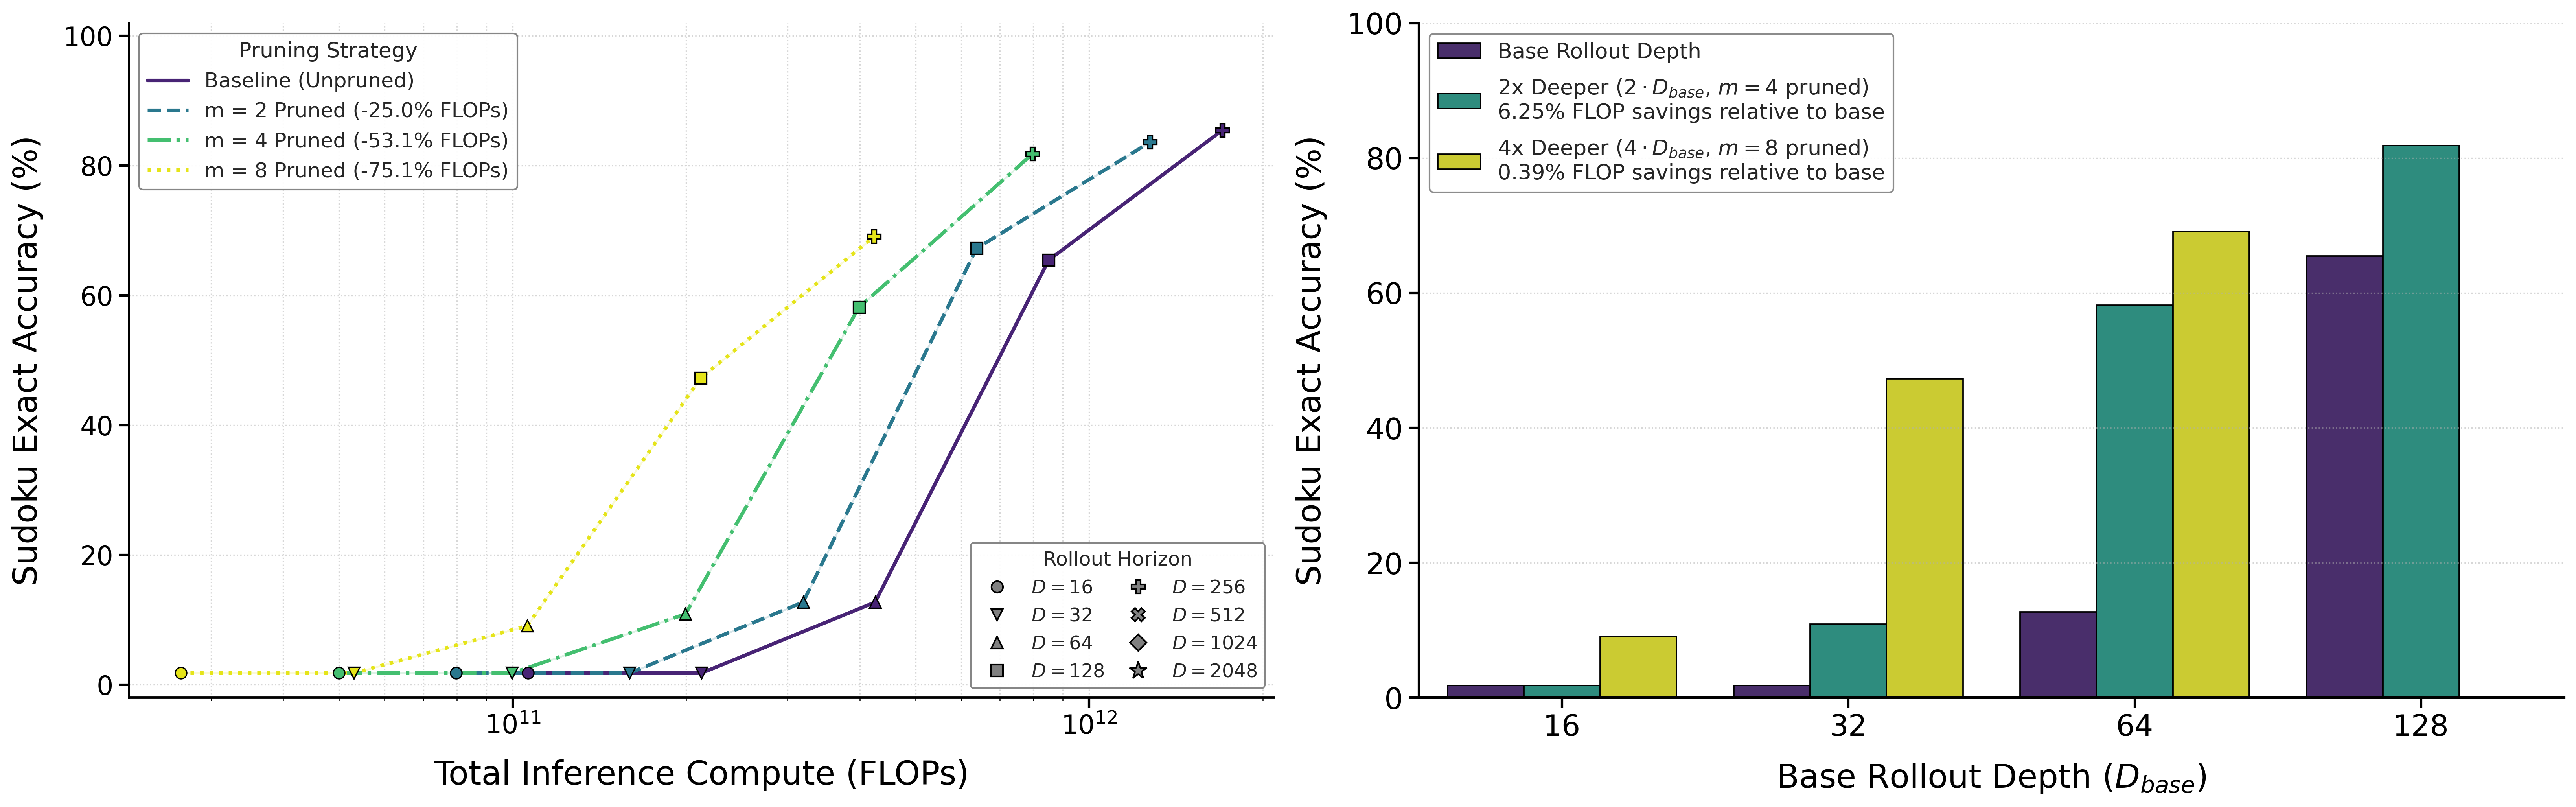

In [11]:
#@title Visualize Results

def visualize_results(df_sum: pd.DataFrame, df_det: pd.DataFrame, target_K: int = None):
  if df_sum.empty or df_det.empty:
    print("No results to plot yet.")
    return

  if target_K is None:
    target_K = int(df_sum["K"].iloc[0])

  df_sum_k = df_sum[df_sum["K"] == target_K].copy()
  df_sum_k["type"] = df_sum_k["type"].astype(str)

  df_det_k = df_det[df_det["K"] == target_K].copy()
  df_det_k["type"] = df_det_k["type"].astype(str)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), dpi=300)
  sns.set_theme(style="ticks")

  # ----------------------------------------------------------------------------
  # Left Panel (ax1): Compute-Accuracy Pareto Scaling Curves
  # ----------------------------------------------------------------------------
  strategy_map = {
      "baseline": ("Baseline (Unpruned)", plt.cm.viridis(0.10), "-"),
      "2": ("m = 2 Pruned (-25.0% FLOPs)", plt.cm.viridis(0.40), "--"),
      "4": ("m = 4 Pruned (-53.1% FLOPs)", plt.cm.viridis(0.70), "-."),
      "8": ("m = 8 Pruned (-75.1% FLOPs)", plt.cm.viridis(0.96), ":"),
  }

  horizon_markers = {
      16: ("o", 7),
      32: ("v", 7),
      64: ("^", 7),
      128: ("s", 7),
      256: ("P", 8),
      512: ("X", 8),
      1024: ("D", 7),
      2048: ("*", 11),
  }

  for s_type, (s_label, color, l_style) in strategy_map.items():
    sub = df_sum_k[df_sum_k["type"] == s_type].sort_values("T")
    flops_list, acc_list, std_list = [], [], []

    for _, r in sub.iterrows():
      T_val = int(r["T"])
      if T_val in horizon_markers:
        f_val = float(r["flops"])
        a_val = float(r["mean_acc"]) * 100
        s_val = float(r["std_acc"]) * 100 if "std_acc" in r else 0.0
        flops_list.append(f_val)
        acc_list.append(a_val)
        std_list.append(s_val)

        m_shape, m_size = horizon_markers[T_val]
        ax1.plot(
            f_val,
            a_val,
            marker=m_shape,
            markersize=m_size,
            color=color,
            markeredgecolor="black",
            markeredgewidth=0.8,
            zorder=4,
        )

    if not flops_list:
      continue

    f_arr = np.array(flops_list)
    a_arr = np.array(acc_list)
    s_arr = np.array(std_list)

    ax1.fill_between(
        f_arr,
        a_arr - s_arr,
        a_arr + s_arr,
        color=color,
        alpha=0.18,
        zorder=2,
    )
    ax1.plot(
        f_arr,
        a_arr,
        color=color,
        linestyle=l_style,
        linewidth=2.2,
        zorder=3,
    )

  ax1.set_xscale("log")
  ax1.set_xlabel("Total Inference Compute (FLOPs)", fontsize=20, fontweight="normal", labelpad=12)
  ax1.set_ylabel("Sudoku Exact Accuracy (%)", fontsize=20, fontweight="normal", labelpad=12)
  ax1.set_ylim(-2, 102)
  ax1.grid(True, linestyle=":", alpha=0.5, which="both")
  ax1.tick_params(axis="both", which="major", labelsize=16, length=6, width=1.5)
  for spine in ax1.spines.values():
    spine.set_linewidth(1.4)

  strat_handles = [
      Line2D([0], [0], color=color, linestyle=l_style, linewidth=2.2, label=s_label)
      for s_type, (s_label, color, l_style) in strategy_map.items()
  ]
  leg1 = ax1.legend(
      handles=strat_handles,
      loc="upper left",
      fontsize=12.5,
      frameon=True,
      facecolor="white",
      framealpha=0.95,
      edgecolor="gray",
      title="Pruning Strategy",
      title_fontsize=13,
  )
  leg1.get_title().set_fontweight("normal")
  for text in leg1.get_texts():
    text.set_fontweight("normal")
  ax1.add_artist(leg1)

  horizon_handles = [
      Line2D([0], [0], marker=m_shape, markersize=m_size, color="gray", markeredgecolor="black", linestyle="none", label=f"$D = {T_val}$")
      for T_val, (m_shape, m_size) in horizon_markers.items()
  ]
  leg2 = ax1.legend(
      handles=horizon_handles,
      loc="lower right",
      ncol=2,
      columnspacing=0.8,
      fontsize=11.5,
      frameon=True,
      facecolor="white",
      framealpha=0.95,
      edgecolor="gray",
      title="Rollout Horizon",
      title_fontsize=12,
  )
  leg2.get_title().set_fontweight("normal")
  for text in leg2.get_texts():
    text.set_fontweight("normal")

  # ----------------------------------------------------------------------------
  # Right Panel (ax2): Iso-Compute Accuracy Comparison
  # ----------------------------------------------------------------------------
  available_T = sorted(df_det_k["T"].unique())
  base_horizons = [
      T for T in [16, 32, 64, 128, 256, 512]
      if T in available_T and ((T * 2 in available_T) or (T * 4 in available_T))
  ]
  if not base_horizons:
    base_horizons = available_T

  plot_data = []
  for T in base_horizons:
    sub_base = df_det_k[(df_det_k["T"] == T) & (df_det_k["type"] == "baseline")]
    for _, r in sub_base.iterrows():
      plot_data.append({
          "Base Horizon": T,
          "Strategy": "Base Rollout Depth",
          "Accuracy": float(r["acc"]) * 100,
          "Seed": int(r["eval_seed"]),
      })

    t_2x = T * 2
    sub_2x = df_det_k[(df_det_k["T"] == t_2x) & (df_det_k["type"] == "4")]
    for _, r in sub_2x.iterrows():
      plot_data.append({
          "Base Horizon": T,
          "Strategy": "2x Deeper ($2\\cdot D_{base}$, $m=4$ pruned)\n6.25% FLOP savings relative to base",
          "Accuracy": float(r["acc"]) * 100,
          "Seed": int(r["eval_seed"]),
      })

    t_4x = T * 4
    sub_4x = df_det_k[(df_det_k["T"] == t_4x) & (df_det_k["type"] == "8")]
    for _, r in sub_4x.iterrows():
      plot_data.append({
          "Base Horizon": T,
          "Strategy": "4x Deeper ($4\\cdot D_{base}$, $m=8$ pruned)\n0.39% FLOP savings relative to base",
          "Accuracy": float(r["acc"]) * 100,
          "Seed": int(r["eval_seed"]),
      })

  df_plot = pd.DataFrame(plot_data)
  palette = [plt.cm.viridis(0.10), plt.cm.viridis(0.55), plt.cm.viridis(0.96)]

  sns.barplot(
      data=df_plot,
      x="Base Horizon",
      y="Accuracy",
      hue="Strategy",
      palette=palette,
      errorbar="sd",
      capsize=0.10,
      err_kws={"linewidth": 1.4, "color": "black"},
      edgecolor="black",
      linewidth=0.9,
      ax=ax2,
  )

  ax2.set_xlabel(r"Base Rollout Depth ($D_{base}$)", fontsize=20, fontweight="normal", labelpad=12)
  ax2.set_ylabel("Sudoku Exact Accuracy (%)", fontsize=20, fontweight="normal", labelpad=12)
  ax2.set_ylim(0, 100)
  ax2.grid(True, linestyle=":", alpha=0.5, axis="y")
  ax2.tick_params(axis="both", which="major", labelsize=18, length=6, width=1.5)
  for spine in ax2.spines.values():
    spine.set_linewidth(1.5)

  legend2 = ax2.legend(
      loc="upper left",
      fontsize=13,
      labelspacing=0.7,
      frameon=True,
      facecolor="white",
      framealpha=0.9,
      edgecolor="gray",
  )
  for text in legend2.get_texts():
    text.set_fontweight("normal")

  sns.despine(top=True, right=True)
  plt.tight_layout()
  plt.show()


visualize_results(summary_df, detailed_df, target_K=SEEDS_N)